# The Object Detection Dataset
:label:`sec_object-detection-dataset`

There is no small dataset such as MNIST and Fashion-MNIST in the field of object detection.
In order to quickly demonstrate object detection models,
[**we collected and labeled a small dataset**].
First, we took photos of free bananas from our office
and generated
1000 banana images with different rotations and sizes.
Then we placed each banana image
at a random position on some background image.
In the end, we labeled bounding boxes for those bananas on the images.


## Downloading the Dataset

The banana detection dataset with all the image and
csv label files can be downloaded directly from the Internet.

In [27]:
using Pkg;
Pkg.activate("../../d2lai")
using d2lai, Flux, DataFrames, CSV
using Images, DataAugmentation, Plots
file = d2lai._download("banana-detection.zip")


  Activating project at `~/d2l-julia/d2lai`


"/tmp/jl_3kLi0B/banana-detection.zip"

## Reading the Dataset

We are going to [**read the banana detection dataset**] in the `read_data_bananas`
function below.
The dataset includes a csv file for
object class labels and
ground-truth bounding box coordinates
at the upper-left and lower-right corners.


In [4]:
function read_data_bananas(extracted_folder; train = true)
    folder = train ? "bananas_train" : "bananas_val"
    folder_path = joinpath(extracted_folder, "banana-detection", folder)
    df = DataFrame(CSV.File(joinpath(folder_path, "label.csv")))
    img_names = df[!, 1]
    targets = df[!, 2:end] |> Array 
    targets = permutedims(targets, (2, 1))
    images = map(img_names) do img_name 
        img = Images.load(joinpath(folder_path, "images", img_name))
        img = Image(img)
        img_tensor = apply(ImageToTensor(), img) |> itemdata
        img_tensor = permutedims(img_tensor, (2,1,3))
    end
    
    images = stack(images; dims = 4)

    images, Flux.unsqueeze(targets, dims = 1) ./ 256
end


read_data_bananas (generic function with 1 method)

By using the read_data_bananas function to read images and labels, the following `BananasDataset` struct will allow us to create a customized Dataset instance for loading the banana detection dataset.



In [5]:

struct BananaDataset{T,V,A} <: AbstractData 
    train_data::T 
    val_data::V 
    args::A
end

function BananaDataset(; batchsize = 32)
    file = d2lai._download("banana-detection.zip")

    extracted_folder = d2lai._extract(file)

    train_data = read_data_bananas(extracted_folder; train = true)
    val_data = read_data_bananas(extracted_folder; train = false)
    args = (; extracted_folder, batchsize)
    BananaDataset(train_data, val_data, args)
end

BananaDataset

Finally, we define the load_data_bananas function to return two data iterator instances for both the training and test sets. For the test dataset, there is no need to read it in random order.



In [6]:
function d2lai.get_dataloader(data::BananaDataset; train = true)
    if train
        Flux.DataLoader(data.train_data; batchsize = data.args.batchsize, shuffle = true)
    else
        Flux.DataLoader(data.val_data; batchsize = data.args.batchsize)
    end
end

function load_data_bananas(data)
    get_dataloader(data), get_dataloader(data; train = false)
end


load_data_bananas (generic function with 1 method)

Let's read a minibatch and print the shapes of
both images and labels in this minibatch.
The shape of the image minibatch,
(batch size, number of channels, height, width),
looks familiar:
it is the same as in our earlier image classification tasks.
The shape of the label minibatch is
(batch size, $m$, 5),
where $m$ is the largest possible number of bounding boxes
that any image has in the dataset.

Although computation in minibatches is more efficient,
it requires that all the image examples
contain the same number of bounding boxes to form a minibatch via concatenation.
In general,
images may have a varying number of bounding boxes;
thus,
images with fewer than $m$ bounding boxes
will be padded with illegal bounding boxes
until $m$ is reached.
Then
the label of each bounding box is represented by an array of length 5.
The first element in the array is the class of the object in the bounding box,
where -1 indicates an illegal bounding box for padding.
The remaining four elements of the array are
the ($x$, $y$)-coordinate values
of the upper-left corner and the lower-right corner
of the bounding box (the range is between 0 and 1).
For the banana dataset,
since there is only one bounding box on each image,
we have $m=1$.


In [16]:
batchsize, edge_size = 32, 256
data = BananaDataset(; batchsize = batchsize)
train_iter, _ = load_data_bananas(data)
batch = first(train_iter)
size(batch[1]), size(batch[2])

((256, 256, 3, 32), (1, 5, 32))

## Demonstration

Let's demonstrate ten images with their labeled ground-truth bounding boxes.
We can see that the rotations, sizes, and positions of bananas vary across all these images.
Of course, this is just a simple artificial dataset.
In practice, real-world datasets are usually much more complicated.

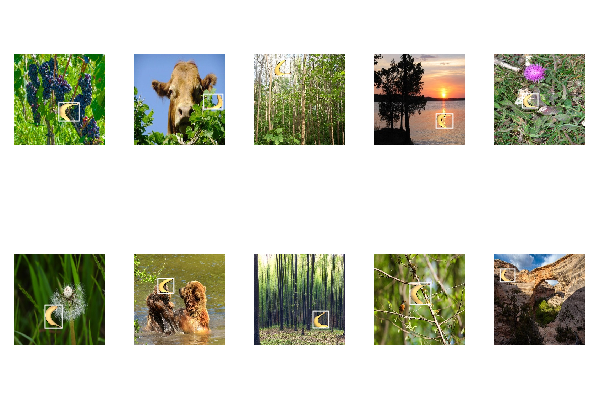

In [52]:
plts = map(eachslice(batch[1], dims = 4), eachslice(batch[2], dims = 3)) do img, label
    img_plt = d2lai.show_image(img) |> plot
    img_plt = d2lai.show_bboxes(img_plt, label[:, 2:5]*edge_size; colors = [:white])
end
plot(plts[1:10]..., layout = (2, 5), axis = nothing, yaxis = false, legend = false, xaxis=false)

## Summary

* The banana detection dataset we collected can be used to demonstrate object detection models.
* The data loading for object detection is similar to that for image classification. However, in object detection the labels also contain information of ground-truth bounding boxes, which is missing in image classification.


## Exercises

1. Demonstrate other images with ground-truth bounding boxes in the banana detection dataset. How do they differ with respect to bounding boxes and objects?
1. Say that we want to apply data augmentation, such as random cropping, to object detection. How can it be different from that in image classification? Hint: what if a cropped image only contains a small portion of an object?
